# HW#2-9: 영상 이진화 비교

Rice 영상(불균일 조명)을 이진화한다. 수업시간에 배운 2가지 방법을 비교한다.
- Global Thresholding (Otsu)
- Adaptive Thresholding (지역 이진화)

Image shape: (600, 600), dtype: uint8


/var/folders/1v/jvd6xf6n6dj2540cb9cq1ht00000gn/T/ipykernel_66287/3349183136.py:13: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.10; the parameter will become keyword-only in 3.12.
  axes[1].hist(img.ravel(), 256, [0, 256], color='gray')


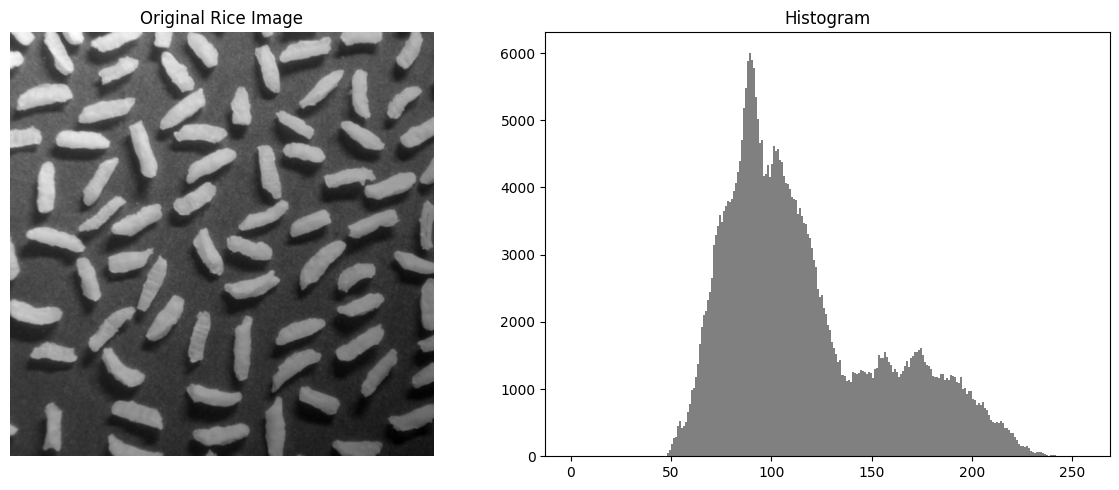

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('data/Fig0940(a)(rice_image_with_intensity_gradient).tif', cv2.IMREAD_GRAYSCALE)
print(f'Image shape: {img.shape}, dtype: {img.dtype}')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(img, cmap='gray')
axes[0].set_title('Original Rice Image')
axes[0].axis('off')

axes[1].hist(img.ravel(), 256, [0, 256], color='gray')
axes[1].set_title('Histogram')
plt.tight_layout()
plt.show()

## 방법 1: Global Thresholding (Otsu)

전체 영상에 대해 하나의 최적 threshold를 자동으로 결정한다.  
클래스 간 분산(between-class variance)을 최대화하는 threshold를 찾는다.

Otsu threshold: 134.0


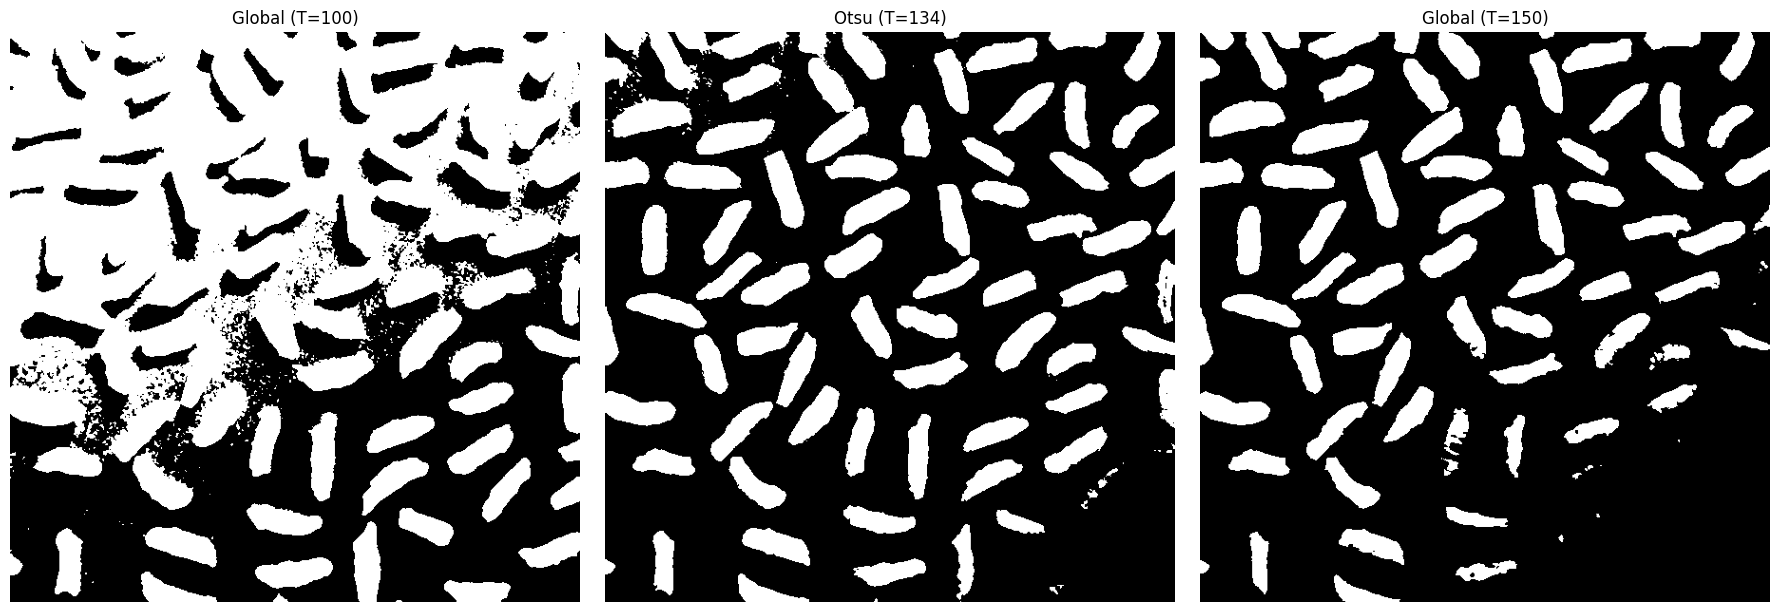

In [2]:
# Otsu's thresholding
ret_otsu, binary_otsu = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
print(f'Otsu threshold: {ret_otsu}')

# 수동 threshold도 비교
_, binary_manual_low = cv2.threshold(img, 100, 255, cv2.THRESH_BINARY)
_, binary_manual_high = cv2.threshold(img, 150, 255, cv2.THRESH_BINARY)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(binary_manual_low, cmap='gray')
axes[0].set_title('Global (T=100)')
axes[0].axis('off')

axes[1].imshow(binary_otsu, cmap='gray')
axes[1].set_title(f'Otsu (T={ret_otsu:.0f})')
axes[1].axis('off')

axes[2].imshow(binary_manual_high, cmap='gray')
axes[2].set_title('Global (T=150)')
axes[2].axis('off')

plt.tight_layout()
plt.show()

## 방법 2: Adaptive Thresholding

각 픽셀의 주변 영역(block)을 기반으로 지역적 threshold를 계산한다.  
불균일 조명에서 전역 threshold보다 훨씬 효과적이다.
- Mean: 주변 픽셀의 평균
- Gaussian: 가우시안 가중 평균

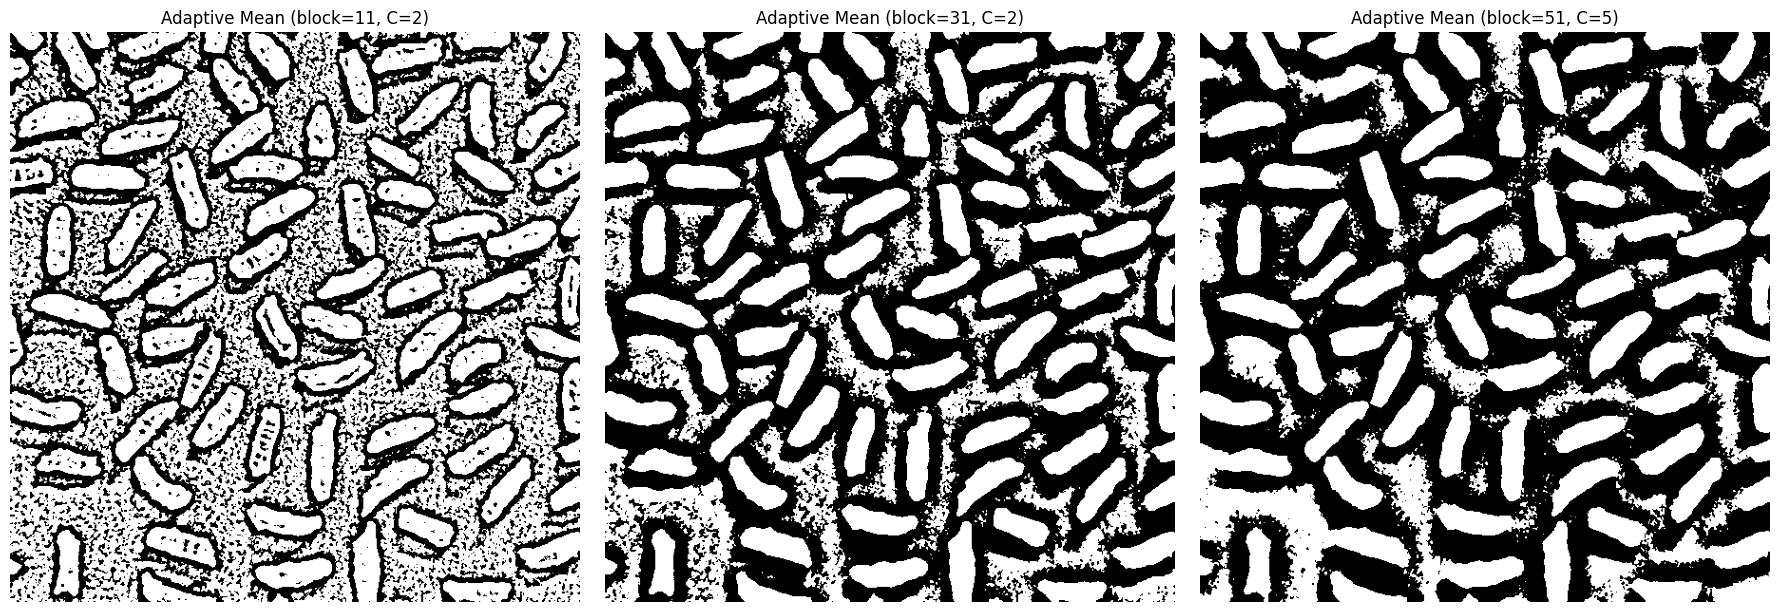

In [3]:
# Adaptive Thresholding - Mean
adapt_mean_11 = cv2.adaptiveThreshold(img, 255, cv2.ADAPTIVE_THRESH_MEAN_C,
                                       cv2.THRESH_BINARY, 11, 2)
adapt_mean_31 = cv2.adaptiveThreshold(img, 255, cv2.ADAPTIVE_THRESH_MEAN_C,
                                       cv2.THRESH_BINARY, 31, 2)
adapt_mean_51 = cv2.adaptiveThreshold(img, 255, cv2.ADAPTIVE_THRESH_MEAN_C,
                                       cv2.THRESH_BINARY, 51, 5)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(adapt_mean_11, cmap='gray')
axes[0].set_title('Adaptive Mean (block=11, C=2)')
axes[0].axis('off')

axes[1].imshow(adapt_mean_31, cmap='gray')
axes[1].set_title('Adaptive Mean (block=31, C=2)')
axes[1].axis('off')

axes[2].imshow(adapt_mean_51, cmap='gray')
axes[2].set_title('Adaptive Mean (block=51, C=5)')
axes[2].axis('off')

plt.tight_layout()
plt.show()

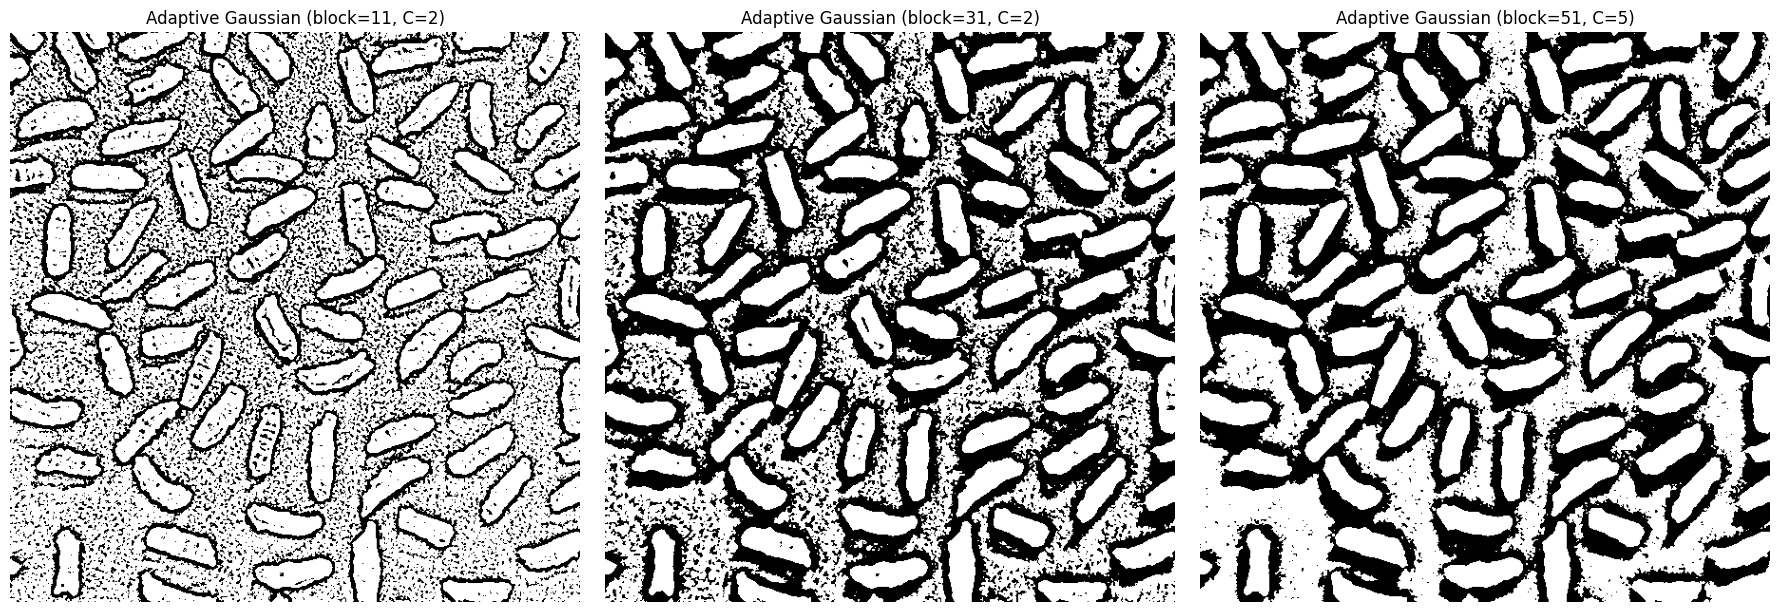

In [4]:
# Adaptive Thresholding - Gaussian
adapt_gauss_11 = cv2.adaptiveThreshold(img, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                        cv2.THRESH_BINARY, 11, 2)
adapt_gauss_31 = cv2.adaptiveThreshold(img, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                        cv2.THRESH_BINARY, 31, 2)
adapt_gauss_51 = cv2.adaptiveThreshold(img, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                        cv2.THRESH_BINARY, 51, 5)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(adapt_gauss_11, cmap='gray')
axes[0].set_title('Adaptive Gaussian (block=11, C=2)')
axes[0].axis('off')

axes[1].imshow(adapt_gauss_31, cmap='gray')
axes[1].set_title('Adaptive Gaussian (block=31, C=2)')
axes[1].axis('off')

axes[2].imshow(adapt_gauss_51, cmap='gray')
axes[2].set_title('Adaptive Gaussian (block=51, C=5)')
axes[2].axis('off')

plt.tight_layout()
plt.show()

## 전체 비교

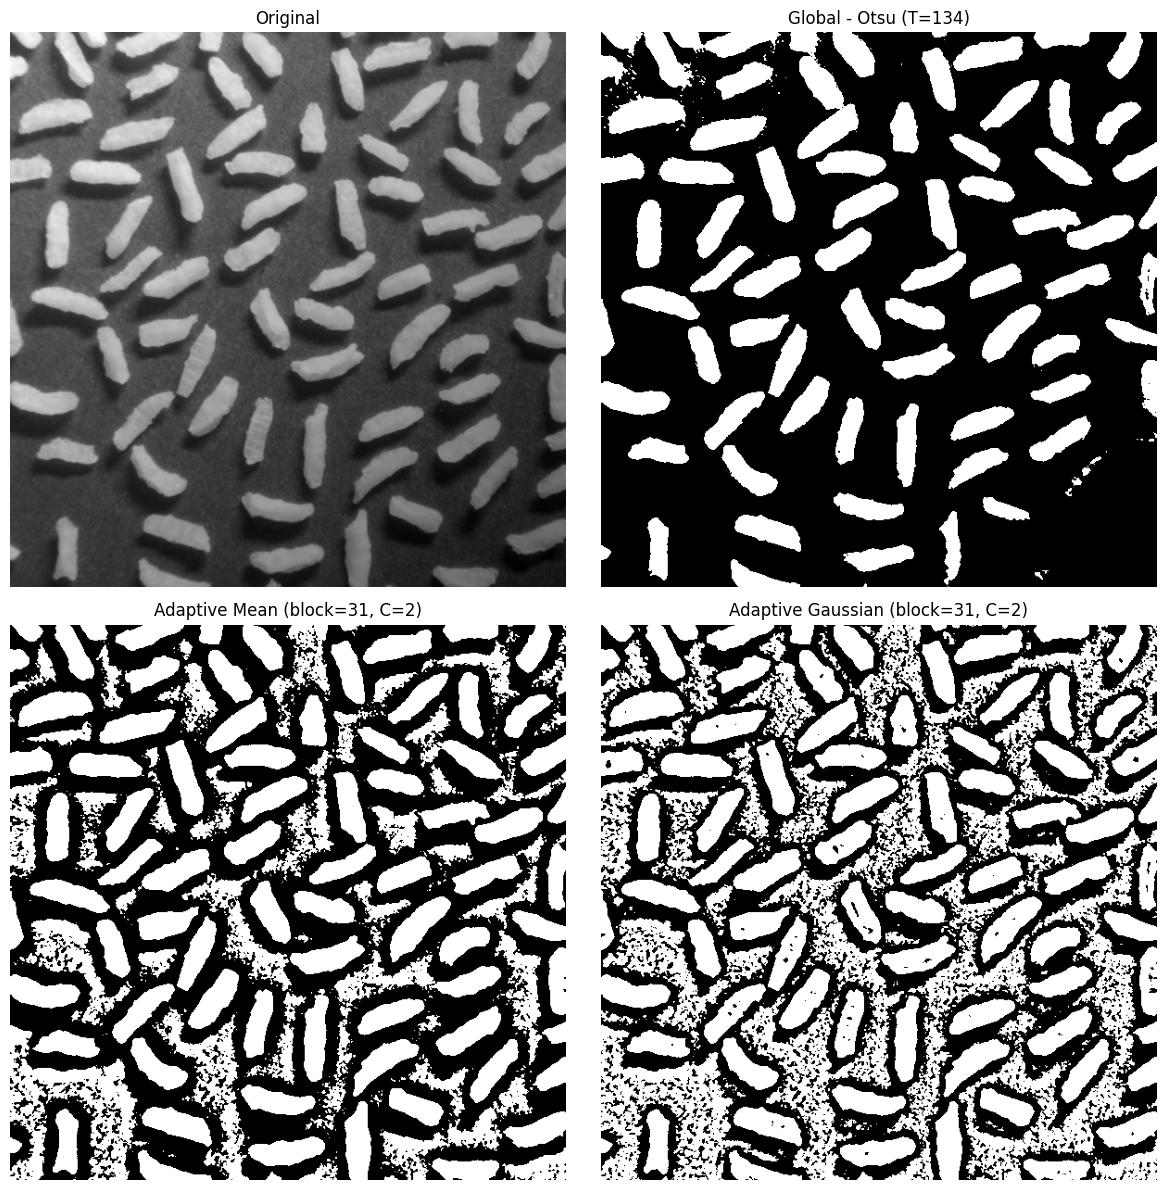

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 12))

axes[0, 0].imshow(img, cmap='gray')
axes[0, 0].set_title('Original')
axes[0, 0].axis('off')

axes[0, 1].imshow(binary_otsu, cmap='gray')
axes[0, 1].set_title(f'Global - Otsu (T={ret_otsu:.0f})')
axes[0, 1].axis('off')

axes[1, 0].imshow(adapt_mean_31, cmap='gray')
axes[1, 0].set_title('Adaptive Mean (block=31, C=2)')
axes[1, 0].axis('off')

axes[1, 1].imshow(adapt_gauss_31, cmap='gray')
axes[1, 1].set_title('Adaptive Gaussian (block=31, C=2)')
axes[1, 1].axis('off')

plt.tight_layout()
plt.savefig('result/hw2_9_result.png', dpi=150, bbox_inches='tight')
plt.show()

## 결과 분석

**Global Thresholding (Otsu):**
- 하나의 threshold를 전체 영상에 적용하므로, 불균일 조명에 취약하다.
- 이 영상은 왼쪽 상단이 밝고 오른쪽 하단이 어두운 intensity gradient가 있다.
- Otsu 결과를 보면 밝은 영역에서는 쌀알이 잘 분리되지만, 어두운 영역에서는 배경까지 전경으로 분류되어 이진화가 실패한다.

**Adaptive Thresholding:**
- 각 픽셀 주변의 지역적 밝기를 기준으로 threshold를 결정하므로, 불균일 조명의 영향을 받지 않는다.
- 영상 전체에 걸쳐 쌀알이 고르게 분리된다.
- block size가 작으면 노이즈에 민감하고, 크면 지역적 변화에 둔감해진다.
- C 값이 클수록 threshold가 낮아져 더 많은 영역이 전경으로 분류된다.
- Mean과 Gaussian의 차이는 미미하지만, Gaussian이 약간 더 부드러운 결과를 낸다.

**결론:**  
불균일 조명이 있는 영상에서는 Global thresholding이 근본적으로 한계가 있으며, Adaptive thresholding이 훨씬 효과적이다.